# Analyze Visit Data From an Outpatient Clinic

In [ ]:
# this script analyzes the demo_hospital_outpatient_data_NHC.csv dataset
# this is a demo visit dataset of the outpatient department of an hypothetical hospital
# the dataset has 1M observations and 13 fields

In [1]:
# before importing any library, run the statements below in the terminal
# when installing any package, make sure to be in the proper environment!
# conda install anaconda::pandas
# conda install anaconda::openpyxl
# conda install conda-forge::pyreadstat
# conda install conda-forge::matplotlib
# conda install conda-forge::seaborn

import pandas as pd
import zipfile
import pyreadstat
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# assign the paths to the input and output file folders to a variable for reproducibility (and privacy)
input_folder_path = "path/to/input/file/folder/"
output_folder_path = "path/to/output/file/folder/"

## 01: Explore the Dataset

In [3]:
# read a CSV file into a data frame
df_visit = pd.read_csv(input_folder_path+"demo_hospital_outpatient_data_NHC.csv")
df_visit

,Visit_Date,Patient_ID,Age,Gender,Diagnosis,Has_Insurance,Postcode,Total_Cost,Registration,Nursing,Laboratory,Consultation,Pharmacy
0,2020-05-06,688923,68,Female,Diabetes,True,20006,2274.0,33,105,101,28,112
1,2018-08-04,886361,62,Female,Urinary Tract Infection,False,20005,3430.0,46,75,84,102,36
2,2021-04-10,464823,70,Female,Upper Respiratory Tract Infection,True,10003,1836.0,107,81,5,77,36
3,2021-10-01,655214,8,Female,Upper Respiratory Tract Infection,False,10006,3250.0,66,31,101,35,92
4,2018-04-30,454666,24,Male,Malaria,True,10006,2262.0,68,55,60,90,104
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,2018-09-30,385435,9,Male,Abdominal pain,True,10004,1458.0,80,52,11,42,58
999996,2020-05-08,117261,29,Female,Urinary Tract Infection,True,20009,1836.0,59,57,64,66,60
999997,2019-12-31,594613,39,Female,Upper Respiratory Tract Infection,False,10001,1930.0,10,14,69,14,86
999998,2019-11-04,152179,39,Female,Malaria,False,20006,3950.0,119,52,60,94,70


In [4]:
# get a concise summary of a data frame
df_visit.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   Visit_Date     1000000 non-null  str    
 1   Patient_ID     1000000 non-null  int64  
 2   Age            1000000 non-null  int64  
 3   Gender         1000000 non-null  str    
 4   Diagnosis      1000000 non-null  str    
 5   Has_Insurance  1000000 non-null  bool   
 6   Postcode       1000000 non-null  int64  
 7   Total_Cost     1000000 non-null  float64
 8   Registration   1000000 non-null  int64  
 9   Nursing        1000000 non-null  int64  
 10  Laboratory     1000000 non-null  int64  
 11  Consultation   1000000 non-null  int64  
 12  Pharmacy       1000000 non-null  int64  
dtypes: bool(1), float64(1), int64(8), str(3)
memory usage: 92.5 MB


In [ ]:
# check whether there are empty rows
# is.na() returns a boolean same-sized object indicating if the values are (not) NAs
df_visit.isna()

,Visit_Date,Patient_ID,Age,Gender,Diagnosis,Has_Insurance,Postcode,Total_Cost,Registration,Nursing,Laboratory,Consultation,Pharmacy
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,False,False,False,False,False,False,False,False,False,False,False,False,False
999996,False,False,False,False,False,False,False,False,False,False,False,False,False
999997,False,False,False,False,False,False,False,False,False,False,False,False,False
999998,False,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
# get the total number of NA (i.e., TRUE) values for each field
df_visit.isna().sum()

Visit_Date       0
Patient_ID       0
Age              0
Gender           0
Diagnosis        0
Has_Insurance    0
Postcode         0
Total_Cost       0
Registration     0
Nursing          0
Laboratory       0
Consultation     0
Pharmacy         0
dtype: int64

In [7]:
# all rows seems to be complete (i.e., without missing values)
# however, let's say there were any missing values
# one could remove them as follows
df_visit = df_visit.dropna()

In [8]:
# see the first five rows
# to return a different number of rows, specify it e.g., df_visit.head(20)
df_visit.head()

,Visit_Date,Patient_ID,Age,Gender,Diagnosis,Has_Insurance,Postcode,Total_Cost,Registration,Nursing,Laboratory,Consultation,Pharmacy
0,2020-05-06,688923,68,Female,Diabetes,True,20006,2274.0,33,105,101,28,112
1,2018-08-04,886361,62,Female,Urinary Tract Infection,False,20005,3430.0,46,75,84,102,36
2,2021-04-10,464823,70,Female,Upper Respiratory Tract Infection,True,10003,1836.0,107,81,5,77,36
3,2021-10-01,655214,8,Female,Upper Respiratory Tract Infection,False,10006,3250.0,66,31,101,35,92
4,2018-04-30,454666,24,Male,Malaria,True,10006,2262.0,68,55,60,90,104


In [9]:
# rename the Registration column to Registration_Minutes
# set the 'inplace' argument to TRUE to modify the "original" data frame
df_visit.rename(columns={"Registration": "Registration_Minutes"}, inplace=True)

In [10]:
df_visit.head()

,Visit_Date,Patient_ID,Age,Gender,Diagnosis,Has_Insurance,Postcode,Total_Cost,Registration_Minutes,Nursing,Laboratory,Consultation,Pharmacy
0,2020-05-06,688923,68,Female,Diabetes,True,20006,2274.0,33,105,101,28,112
1,2018-08-04,886361,62,Female,Urinary Tract Infection,False,20005,3430.0,46,75,84,102,36
2,2021-04-10,464823,70,Female,Upper Respiratory Tract Infection,True,10003,1836.0,107,81,5,77,36
3,2021-10-01,655214,8,Female,Upper Respiratory Tract Infection,False,10006,3250.0,66,31,101,35,92
4,2018-04-30,454666,24,Male,Malaria,True,10006,2262.0,68,55,60,90,104


In [11]:
# similarly, let's rename the Nursing, Laboratory, Consultation, and Pharmacy columns
column_mapping = {"Nursing": "Nursing_Minutes", "Laboratory": "Laboratory_Minutes", "Consultation": "Consultation_Minutes", "Pharmacy": "Pharmacy_Minutes"}
df_visit.rename(columns=column_mapping, inplace=True)
df_visit.head()

,Visit_Date,Patient_ID,Age,Gender,Diagnosis,Has_Insurance,Postcode,Total_Cost,Registration_Minutes,Nursing_Minutes,Laboratory_Minutes,Consultation_Minutes,Pharmacy_Minutes
0,2020-05-06,688923,68,Female,Diabetes,True,20006,2274.0,33,105,101,28,112
1,2018-08-04,886361,62,Female,Urinary Tract Infection,False,20005,3430.0,46,75,84,102,36
2,2021-04-10,464823,70,Female,Upper Respiratory Tract Infection,True,10003,1836.0,107,81,5,77,36
3,2021-10-01,655214,8,Female,Upper Respiratory Tract Infection,False,10006,3250.0,66,31,101,35,92
4,2018-04-30,454666,24,Male,Malaria,True,10006,2262.0,68,55,60,90,104


## 02: Save and Load the Dataset in a Different Format

In [13]:
# write an object to a CSV file
# set 'index' to FALSE to prevent the presence of a (first) 'Unnamed' column in the output file
df_visit.to_csv(output_folder_path+"demo_hospital_outpatient_data_NHC_clean.csv", index=False)

In [14]:
pd.read_csv(output_folder_path+"demo_hospital_outpatient_data_NHC_clean.csv")

,Visit_Date,Patient_ID,Age,Gender,Diagnosis,Has_Insurance,Postcode,Total_Cost,Registration_Minutes,Nursing_Minutes,Laboratory_Minutes,Consultation_Minutes,Pharmacy_Minutes
0,2020-05-06,688923,68,Female,Diabetes,True,20006,2274.0,33,105,101,28,112
1,2018-08-04,886361,62,Female,Urinary Tract Infection,False,20005,3430.0,46,75,84,102,36
2,2021-04-10,464823,70,Female,Upper Respiratory Tract Infection,True,10003,1836.0,107,81,5,77,36
3,2021-10-01,655214,8,Female,Upper Respiratory Tract Infection,False,10006,3250.0,66,31,101,35,92
4,2018-04-30,454666,24,Male,Malaria,True,10006,2262.0,68,55,60,90,104
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,2018-09-30,385435,9,Male,Abdominal pain,True,10004,1458.0,80,52,11,42,58
999996,2020-05-08,117261,29,Female,Urinary Tract Infection,True,20009,1836.0,59,57,64,66,60
999997,2019-12-31,594613,39,Female,Upper Respiratory Tract Infection,False,10001,1930.0,10,14,69,14,86
999998,2019-11-04,152179,39,Female,Malaria,False,20006,3950.0,119,52,60,94,70


In [15]:
# write an object to an Excel sheet
# it almost took six minutes...
df_visit.to_excel(output_folder_path+"demo_hospital_outpatient_data_NHC_clean.xlsx", index=False)

In [ ]:
# read an Excel file into a data frame
# it almost took four minutes...
pd.read_excel(output_folder_path+"demo_hospital_outpatient_data_NHC_clean.xlsx")

,Visit_Date,Patient_ID,Age,Gender,Diagnosis,Has_Insurance,Postcode,Total_Cost,Registration_Minutes,Nursing_Minutes,Laboratory_Minutes,Consultation_Minutes,Pharmacy_Minutes
0,2020-05-06,688923,68,Female,Diabetes,True,20006,2274,33,105,101,28,112
1,2018-08-04,886361,62,Female,Urinary Tract Infection,False,20005,3430,46,75,84,102,36
2,2021-04-10,464823,70,Female,Upper Respiratory Tract Infection,True,10003,1836,107,81,5,77,36
3,2021-10-01,655214,8,Female,Upper Respiratory Tract Infection,False,10006,3250,66,31,101,35,92
4,2018-04-30,454666,24,Male,Malaria,True,10006,2262,68,55,60,90,104
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,2018-09-30,385435,9,Male,Abdominal pain,True,10004,1458,80,52,11,42,58
999996,2020-05-08,117261,29,Female,Urinary Tract Infection,True,20009,1836,59,57,64,66,60
999997,2019-12-31,594613,39,Female,Upper Respiratory Tract Infection,False,10001,1930,10,14,69,14,86
999998,2019-11-04,152179,39,Female,Malaria,False,20006,3950,119,52,60,94,70


In [ ]:
# save a data frame to a zipped format
# zipfile.ZipFile() opens a ZIP file in write ("w") mode
# this only took seven seconds!
zipped_file_name = "demo_hospital_outpatient_data_NHC_clean.zip"
with zipfile.ZipFile(zipped_file_name, "w", zipfile.ZIP_DEFLATED) as zip:
    zip.write(output_folder_path+"demo_hospital_outpatient_data_NHC_clean.csv")

In [ ]:
# read the file into a data frame
# this only took 2.6 seconds!
pd.read_csv(output_folder_path+"demo_hospital_outpatient_data_NHC_clean.zip")

,Visit_Date,Patient_ID,Age,Gender,Diagnosis,Has_Insurance,Postcode,Total_Cost,Registration_Minutes,Nursing_Minutes,Laboratory_Minutes,Consultation_Minutes,Pharmacy_Minutes
0,2020-05-06,688923,68,Female,Diabetes,True,20006,2274.0,33,105,101,28,112
1,2018-08-04,886361,62,Female,Urinary Tract Infection,False,20005,3430.0,46,75,84,102,36
2,2021-04-10,464823,70,Female,Upper Respiratory Tract Infection,True,10003,1836.0,107,81,5,77,36
3,2021-10-01,655214,8,Female,Upper Respiratory Tract Infection,False,10006,3250.0,66,31,101,35,92
4,2018-04-30,454666,24,Male,Malaria,True,10006,2262.0,68,55,60,90,104
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,2018-09-30,385435,9,Male,Abdominal pain,True,10004,1458.0,80,52,11,42,58
999996,2020-05-08,117261,29,Female,Urinary Tract Infection,True,20009,1836.0,59,57,64,66,60
999997,2019-12-31,594613,39,Female,Upper Respiratory Tract Infection,False,10001,1930.0,10,14,69,14,86
999998,2019-11-04,152179,39,Female,Malaria,False,20006,3950.0,119,52,60,94,70


In [ ]:
# the cleaned CSV file is about 73.8 MB
# in contrast, the cleaned .zip file is only about 20.5 MB

In [ ]:
# save the data frame as an SPSS file
# this took about 17 seconds
spss_file = "demo_hospital_outpatient_data_NHC_clean.sav"
pyreadstat.write_sav(df_visit, spss_file)

In [ ]:
# store data and metadata in two separate variables
data, meta = pyreadstat.read_sav(output_folder_path+"demo_hospital_outpatient_data_NHC_clean.sav")

In [21]:
data

,Visit_Date,Patient_ID,Age,Gender,Diagnosis,Has_Insurance,Postcode,Total_Cost,Registration_Minutes,Nursing_Minutes,Laboratory_Minutes,Consultation_Minutes,Pharmacy_Minutes
0,2020-05-06,688923.0,68.0,Female,Diabetes,1.0,20006.0,2274.0,33.0,105.0,101.0,28.0,112.0
1,2018-08-04,886361.0,62.0,Female,Urinary Tract Infection,0.0,20005.0,3430.0,46.0,75.0,84.0,102.0,36.0
2,2021-04-10,464823.0,70.0,Female,Upper Respiratory Tract Infection,1.0,10003.0,1836.0,107.0,81.0,5.0,77.0,36.0
3,2021-10-01,655214.0,8.0,Female,Upper Respiratory Tract Infection,0.0,10006.0,3250.0,66.0,31.0,101.0,35.0,92.0
4,2018-04-30,454666.0,24.0,Male,Malaria,1.0,10006.0,2262.0,68.0,55.0,60.0,90.0,104.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,2018-09-30,385435.0,9.0,Male,Abdominal pain,1.0,10004.0,1458.0,80.0,52.0,11.0,42.0,58.0
999996,2020-05-08,117261.0,29.0,Female,Urinary Tract Infection,1.0,20009.0,1836.0,59.0,57.0,64.0,66.0,60.0
999997,2019-12-31,594613.0,39.0,Female,Upper Respiratory Tract Infection,0.0,10001.0,1930.0,10.0,14.0,69.0,14.0,86.0
999998,2019-11-04,152179.0,39.0,Female,Malaria,0.0,20006.0,3950.0,119.0,52.0,60.0,94.0,70.0


In [22]:
meta

metadata_container(column_names=['Visit_Date', 'Patient_ID', 'Age', 'Gender', 'Diagnosis', 'Has_Insurance', 'Postcode', 'Total_Cost', 'Registration_Minutes', 'Nursing_Minutes', 'Laboratory_Minutes', 'Consultation_Minutes', 'Pharmacy_Minutes'], column_labels=[None, None, None, None, None, None, None, None, None, None, None, None, None], column_names_to_labels={'Visit_Date': None, 'Patient_ID': None, 'Age': None, 'Gender': None, 'Diagnosis': None, 'Has_Insurance': None, 'Postcode': None, 'Total_Cost': None, 'Registration_Minutes': None, 'Nursing_Minutes': None, 'Laboratory_Minutes': None, 'Consultation_Minutes': None, 'Pharmacy_Minutes': None}, file_encoding='UTF-8', file_label=None, number_columns=13, number_rows=1000000, variable_value_labels={}, value_labels={}, variable_to_label={}, notes=[], original_variable_types={'Visit_Date': 'A10', 'Patient_ID': 'F8.2', 'Age': 'F8.2', 'Gender': 'A6', 'Diagnosis': 'A33', 'Has_Insurance': 'F8.0', 'Postcode': 'F8.2', 'Total_Cost': 'F8.2', 'Registr

In [23]:
# store data into a (two-dimensional, size-mutable, potentially heterogeneous) tabular data frame
df_visit = pd.DataFrame(data)
df_visit

,Visit_Date,Patient_ID,Age,Gender,Diagnosis,Has_Insurance,Postcode,Total_Cost,Registration_Minutes,Nursing_Minutes,Laboratory_Minutes,Consultation_Minutes,Pharmacy_Minutes
0,2020-05-06,688923.0,68.0,Female,Diabetes,1.0,20006.0,2274.0,33.0,105.0,101.0,28.0,112.0
1,2018-08-04,886361.0,62.0,Female,Urinary Tract Infection,0.0,20005.0,3430.0,46.0,75.0,84.0,102.0,36.0
2,2021-04-10,464823.0,70.0,Female,Upper Respiratory Tract Infection,1.0,10003.0,1836.0,107.0,81.0,5.0,77.0,36.0
3,2021-10-01,655214.0,8.0,Female,Upper Respiratory Tract Infection,0.0,10006.0,3250.0,66.0,31.0,101.0,35.0,92.0
4,2018-04-30,454666.0,24.0,Male,Malaria,1.0,10006.0,2262.0,68.0,55.0,60.0,90.0,104.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,2018-09-30,385435.0,9.0,Male,Abdominal pain,1.0,10004.0,1458.0,80.0,52.0,11.0,42.0,58.0
999996,2020-05-08,117261.0,29.0,Female,Urinary Tract Infection,1.0,20009.0,1836.0,59.0,57.0,64.0,66.0,60.0
999997,2019-12-31,594613.0,39.0,Female,Upper Respiratory Tract Infection,0.0,10001.0,1930.0,10.0,14.0,69.0,14.0,86.0
999998,2019-11-04,152179.0,39.0,Female,Malaria,0.0,20006.0,3950.0,119.0,52.0,60.0,94.0,70.0


## 03: Demographic Analysis Pt. 1

In [24]:
df_visit = pd.read_csv(output_folder_path+"demo_hospital_outpatient_data_NHC_clean.zip")
df_visit

,Visit_Date,Patient_ID,Age,Gender,Diagnosis,Has_Insurance,Postcode,Total_Cost,Registration_Minutes,Nursing_Minutes,Laboratory_Minutes,Consultation_Minutes,Pharmacy_Minutes
0,2020-05-06,688923,68,Female,Diabetes,True,20006,2274.0,33,105,101,28,112
1,2018-08-04,886361,62,Female,Urinary Tract Infection,False,20005,3430.0,46,75,84,102,36
2,2021-04-10,464823,70,Female,Upper Respiratory Tract Infection,True,10003,1836.0,107,81,5,77,36
3,2021-10-01,655214,8,Female,Upper Respiratory Tract Infection,False,10006,3250.0,66,31,101,35,92
4,2018-04-30,454666,24,Male,Malaria,True,10006,2262.0,68,55,60,90,104
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,2018-09-30,385435,9,Male,Abdominal pain,True,10004,1458.0,80,52,11,42,58
999996,2020-05-08,117261,29,Female,Urinary Tract Infection,True,20009,1836.0,59,57,64,66,60
999997,2019-12-31,594613,39,Female,Upper Respiratory Tract Infection,False,10001,1930.0,10,14,69,14,86
999998,2019-11-04,152179,39,Female,Malaria,False,20006,3950.0,119,52,60,94,70


In [25]:
# count the number of occurrences for each value in the 'Gender' column of df_visit
# value_counts() returns a series containing counts of unique values
visit_gender = df_visit["Gender"].value_counts()
visit_gender

Gender
Male      500108
Female    499892
Name: count, dtype: int64

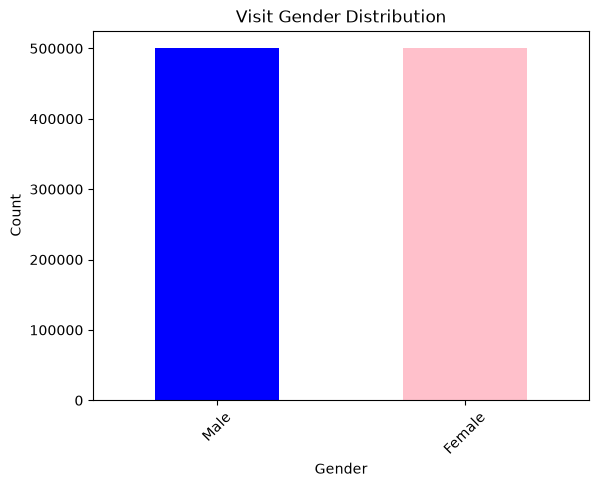

In [ ]:
# visualize them as a bar chart
# the 'rotation' argument of plt.xticks() rotates X-axis labels to the desired angle
visit_gender.plot(kind="bar", color=["blue", "pink"])
plt.title("Visit Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

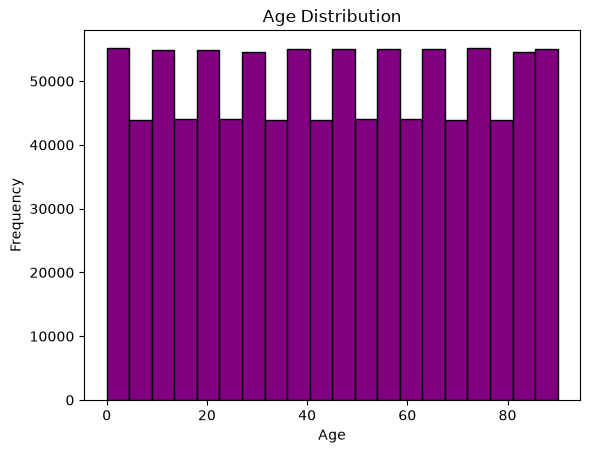

In [27]:
# visualize the distribution of age values as a histogram
# 'bins=20' makes the histogram attempt to split age values into 20 groups
# 'edgecolor="k"' sets the color of column edges to black
plt.hist(df_visit["Age"], bins=20, color="purple", edgecolor="k")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

## 04: Demographic Analysis Pt. 2

In [28]:
# inspect the maximum age of the patients in the dataset
df_visit["Age"].max()

np.int64(90)

In [29]:
# inspect the minimum age of the patients in the dataset
df_visit["Age"].min()

np.int64(0)

In [ ]:
# does an age value of zero refer to a newborn?
# does it refer to a child younger than one year old?

In [30]:
# define bins
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]

# define a new "Age_Range" column
# pd.cut() bins values into discrete intervals
df_visit["Age_Range"] = pd.cut(df_visit["Age"], bins=age_bins)
df_visit

,Visit_Date,Patient_ID,Age,Gender,Diagnosis,Has_Insurance,Postcode,Total_Cost,Registration_Minutes,Nursing_Minutes,Laboratory_Minutes,Consultation_Minutes,Pharmacy_Minutes,Age_Range
0,2020-05-06,688923,68,Female,Diabetes,True,20006,2274.0,33,105,101,28,112,"(60, 70]"
1,2018-08-04,886361,62,Female,Urinary Tract Infection,False,20005,3430.0,46,75,84,102,36,"(60, 70]"
2,2021-04-10,464823,70,Female,Upper Respiratory Tract Infection,True,10003,1836.0,107,81,5,77,36,"(60, 70]"
3,2021-10-01,655214,8,Female,Upper Respiratory Tract Infection,False,10006,3250.0,66,31,101,35,92,"(0, 10]"
4,2018-04-30,454666,24,Male,Malaria,True,10006,2262.0,68,55,60,90,104,"(20, 30]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,2018-09-30,385435,9,Male,Abdominal pain,True,10004,1458.0,80,52,11,42,58,"(0, 10]"
999996,2020-05-08,117261,29,Female,Urinary Tract Infection,True,20009,1836.0,59,57,64,66,60,"(20, 30]"
999997,2019-12-31,594613,39,Female,Upper Respiratory Tract Infection,False,10001,1930.0,10,14,69,14,86,"(30, 40]"
999998,2019-11-04,152179,39,Female,Malaria,False,20006,3950.0,119,52,60,94,70,"(30, 40]"


In [31]:
# for each age range, count the number of patients falling into that range
# sort_index() sorts by index label
age_distribution = df_visit["Age_Range"].value_counts().sort_index()
age_distribution

Age_Range
(0, 10]     110025
(10, 20]    109930
(20, 30]    109577
(30, 40]    109723
(40, 50]    109960
(50, 60]    110259
(60, 70]    110039
(70, 80]    110051
(80, 90]    109515
Name: count, dtype: int64

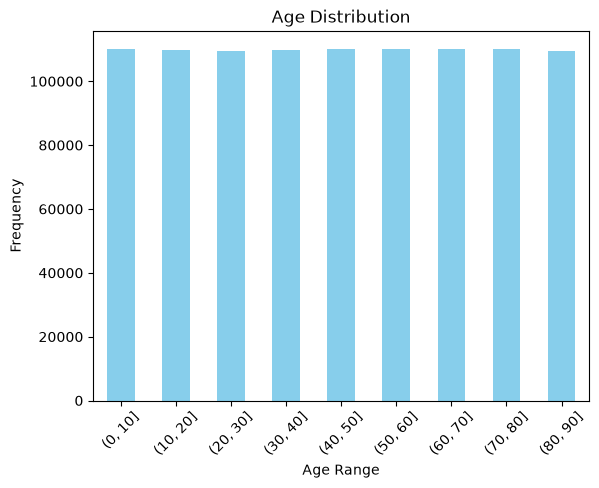

In [32]:
# visualize age distribution using a bar chart
age_distribution.plot(kind="bar", color="skyblue")
plt.title("Age Distribution")
plt.xlabel("Age Range")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

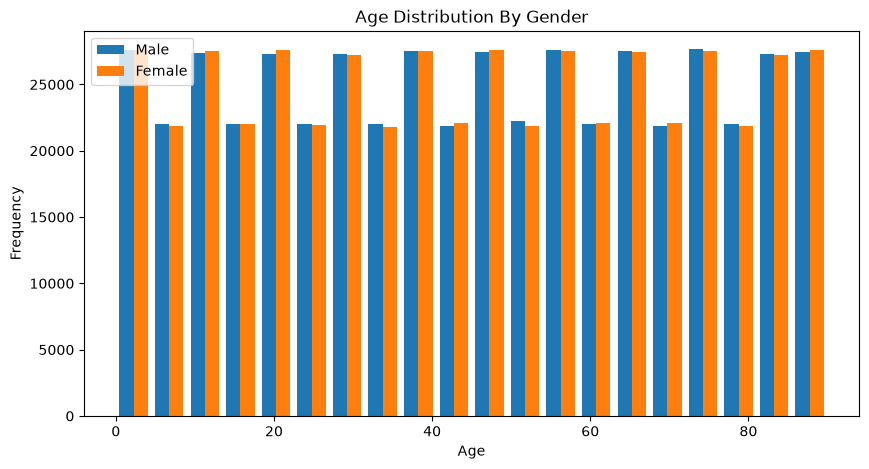

In [35]:
# visualize the age distribution by gender
plt.figure(figsize=(10, 5))
plt.hist([df_visit[df_visit["Gender"] == "Male"]["Age"], df_visit[df_visit["Gender"] == "Female"]["Age"]], bins=20, label=["Male", "Female"])
plt.title("Age Distribution By Gender")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## 05: Trend Analysis of Patient Visits Pt. 1

In [36]:
df_visit = pd.read_csv(output_folder_path+"demo_hospital_outpatient_data_NHC_clean.zip")

In [37]:
# inspect the (first value of the) "Visit_Date" column
df_visit["Visit_Date"][0]

'2020-05-06'

In [38]:
# check its data type
type(df_visit["Visit_Date"][0])

str

In [39]:
# this is actually a string, not a date
# let's convert it to a datetime value
df_visit["Visit_Date"] = pd.to_datetime(df_visit["Visit_Date"])

In [40]:
# check the data type once again
type(df_visit["Visit_Date"][0])

pandas.Timestamp

In [41]:
# index the data frame based on Visit_Date
# this is crucial when performing trend analyses
df_visit.set_index("Visit_Date", inplace=True)
df_visit

,Patient_ID,Age,Gender,Diagnosis,Has_Insurance,Postcode,Total_Cost,Registration_Minutes,Nursing_Minutes,Laboratory_Minutes,Consultation_Minutes,Pharmacy_Minutes
Visit_Date,,,,,,,,,,,,
2020-05-06,688923,68,Female,Diabetes,True,20006,2274.0,33,105,101,28,112
2018-08-04,886361,62,Female,Urinary Tract Infection,False,20005,3430.0,46,75,84,102,36
2021-04-10,464823,70,Female,Upper Respiratory Tract Infection,True,10003,1836.0,107,81,5,77,36
2021-10-01,655214,8,Female,Upper Respiratory Tract Infection,False,10006,3250.0,66,31,101,35,92
2018-04-30,454666,24,Male,Malaria,True,10006,2262.0,68,55,60,90,104
...,...,...,...,...,...,...,...,...,...,...,...,...
2018-09-30,385435,9,Male,Abdominal pain,True,10004,1458.0,80,52,11,42,58
2020-05-08,117261,29,Female,Urinary Tract Infection,True,20009,1836.0,59,57,64,66,60
2019-12-31,594613,39,Female,Upper Respiratory Tract Infection,False,10001,1930.0,10,14,69,14,86


In [42]:
# resample a (time-series) data frame so that it is grouped by year
df_resampled_year = df_visit.resample("YE").count()
df_resampled_year

,Patient_ID,Age,Gender,Diagnosis,Has_Insurance,Postcode,Total_Cost,Registration_Minutes,Nursing_Minutes,Laboratory_Minutes,Consultation_Minutes,Pharmacy_Minutes
Visit_Date,,,,,,,,,,,,
2018-12-31,200016,200016,200016,200016,200016,200016,200016,200016,200016,200016,200016,200016
2019-12-31,200260,200260,200260,200260,200260,200260,200260,200260,200260,200260,200260,200260
2020-12-31,200784,200784,200784,200784,200784,200784,200784,200784,200784,200784,200784,200784
2021-12-31,199663,199663,199663,199663,199663,199663,199663,199663,199663,199663,199663,199663
2022-12-31,199277,199277,199277,199277,199277,199277,199277,199277,199277,199277,199277,199277


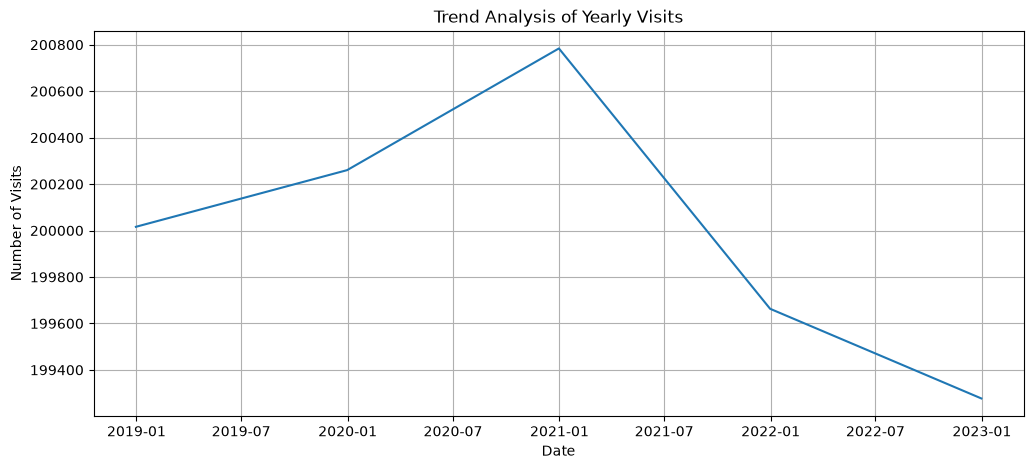

In [43]:
# visualize the number of yearly visits by Patient_ID
# we assume that each Patient_ID is unique to each patient...
# ... and if repeated, it means the same patient came at a separate time
plt.figure(figsize=(12, 5))
plt.plot(df_resampled_year.index, df_resampled_year["Patient_ID"])
plt.title("Trend Analysis of Yearly Visits")
plt.xlabel("Date")
plt.ylabel("Number of Visits")
plt.grid(True)
plt.show()

In [44]:
# resample a (time-series) data frame so that it is grouped by month
df_resampled_month = df_visit.resample("ME").count()
df_resampled_month

,Patient_ID,Age,Gender,Diagnosis,Has_Insurance,Postcode,Total_Cost,Registration_Minutes,Nursing_Minutes,Laboratory_Minutes,Consultation_Minutes,Pharmacy_Minutes
Visit_Date,,,,,,,,,,,,
2018-01-31,16934,16934,16934,16934,16934,16934,16934,16934,16934,16934,16934,16934
2018-02-28,15252,15252,15252,15252,15252,15252,15252,15252,15252,15252,15252,15252
2018-03-31,17159,17159,17159,17159,17159,17159,17159,17159,17159,17159,17159,17159
2018-04-30,16367,16367,16367,16367,16367,16367,16367,16367,16367,16367,16367,16367
2018-05-31,16878,16878,16878,16878,16878,16878,16878,16878,16878,16878,16878,16878
2018-06-30,16636,16636,16636,16636,16636,16636,16636,16636,16636,16636,16636,16636
2018-07-31,16992,16992,16992,16992,16992,16992,16992,16992,16992,16992,16992,16992
2018-08-31,16898,16898,16898,16898,16898,16898,16898,16898,16898,16898,16898,16898
2018-09-30,16353,16353,16353,16353,16353,16353,16353,16353,16353,16353,16353,16353


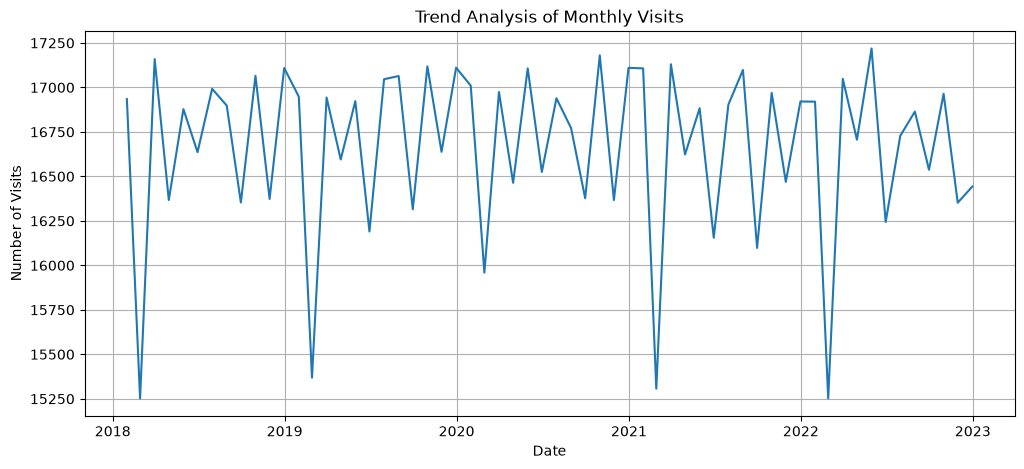

In [45]:
# visualize the number of monthly visits by Patient_ID
plt.figure(figsize=(12, 5))
plt.plot(df_resampled_month.index, df_resampled_month["Patient_ID"])
plt.title("Trend Analysis of Monthly Visits")
plt.xlabel("Date")
plt.ylabel("Number of Visits")
plt.grid(True)
plt.show()

## 06: Trend Analysis of Patient Visits Pt. 2

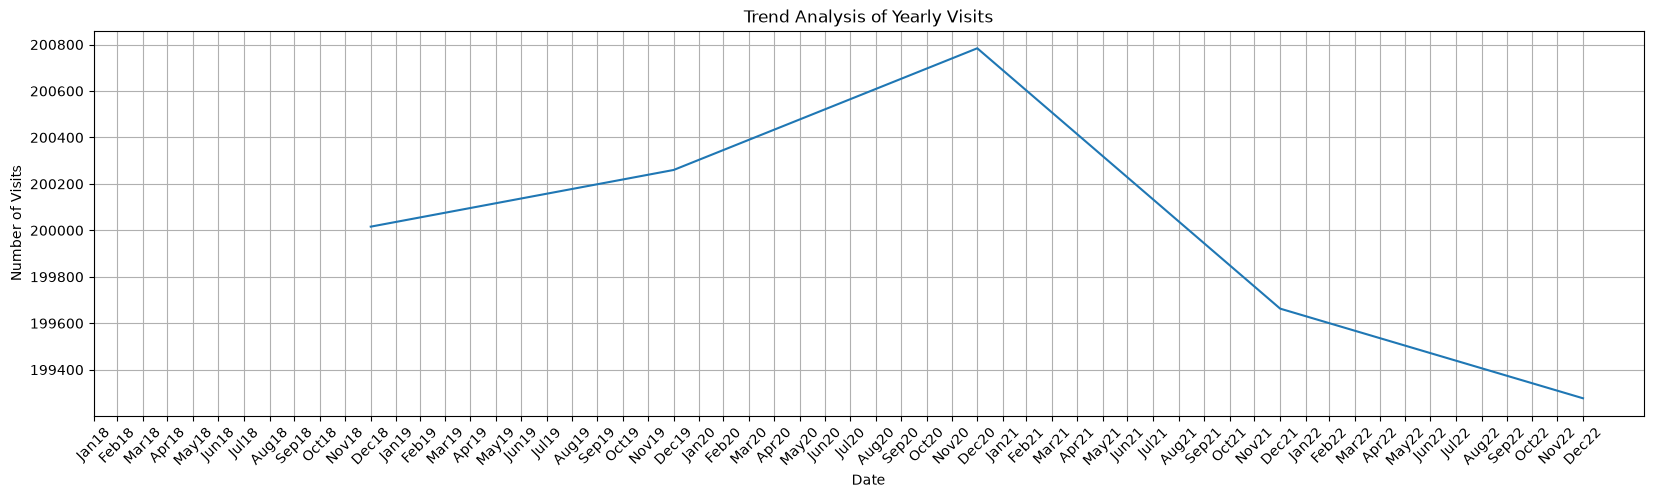

In [ ]:
# visualize the yearly trend of patient visits
monthly_ticks = pd.date_range(start=df_resampled_month.index.min(), end=df_resampled_month.index.max(), freq="ME")
monthly_labels = [date.strftime("%b%y") for date in monthly_ticks]
plt.figure(figsize=(20, 5))
plt.plot(df_resampled_year.index, df_resampled_year["Patient_ID"])
plt.title("Trend Analysis of Yearly Visits")
plt.xticks(monthly_ticks, monthly_labels, rotation=45)
plt.xlabel("Date")
plt.ylabel("Number of Visits")
plt.grid(True)
plt.show()

In [ ]:
# pd.date_range() returns a range of equally spaced time points within the desired range
# here the 'start' and 'end' arguments pull out the index of 'df_resampled_month' (which is a series of month-end dates)
# 'freq="ME"' generates one timestamp per Month-End (i.e., "ME"), matching the same frequency used to build 'df_resampled_month'
# in light of this, monthly_ticks ends up being a list of month-end dates spanning the range of 'df_resampled_month'
# monthly_ticks is essentially the same as df_resampled_month.index, however, building it independently makes it reusable for axis labeling

# monthly_labels is a list built by looping through every item in monthly_ticks...
# ... which are then converted into a text label using .strftime() (i.e., string-format-time)
# in the format code ("%b%y"), "%b" returns the abbreviated month name (e.g., "Jan", "Feb")...
# ... while "%y" returns the two-digit year (e.g., "20" for 2020)
# for instance, a date like 2020-01-31 becomes the string "Jan20"
# in light of this, monthly_labels ends up being a list of these compact date strings (one per entry in monthly_ticks)

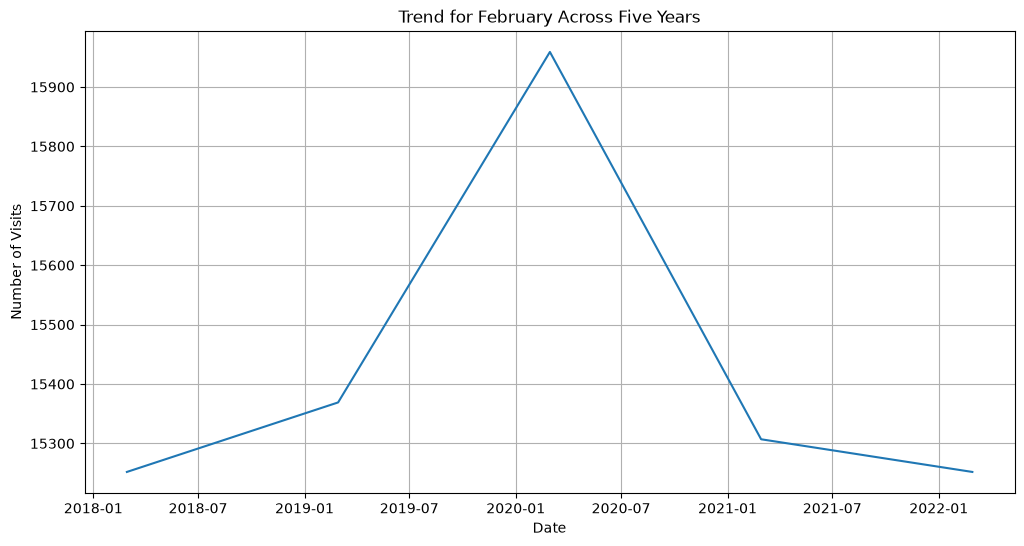

In [47]:
# visualize the trend of a given month (prior to filtering data for it)
# we are starting with February because there was an apparent sharp dip in patient visits in February 2022
target_month = 2
df_target_month = df_resampled_month[df_resampled_month.index.month == target_month]
plt.figure(figsize=(12, 6))
plt.plot(df_target_month.index, df_target_month["Postcode"])
plt.title(f"Trend for {df_target_month.index[0].strftime("%B")} Across Five Years")
plt.xlabel("Date")
plt.ylabel("Number of Visits")
plt.grid(True)
plt.show()

In [ ]:
# here plt.title() builds a dynamic plot title that automatically inserts the correct month name based on how you filter data
# the f-string (f"...") lets you embed Python expressions directly inside a string using curly braces
# whatever is inside the braces gets evaluated and converted to text before the string is used
# in 'strftime("%B")', "%B" returns the full month name
# for instance, for a February date, it returns the string "February"

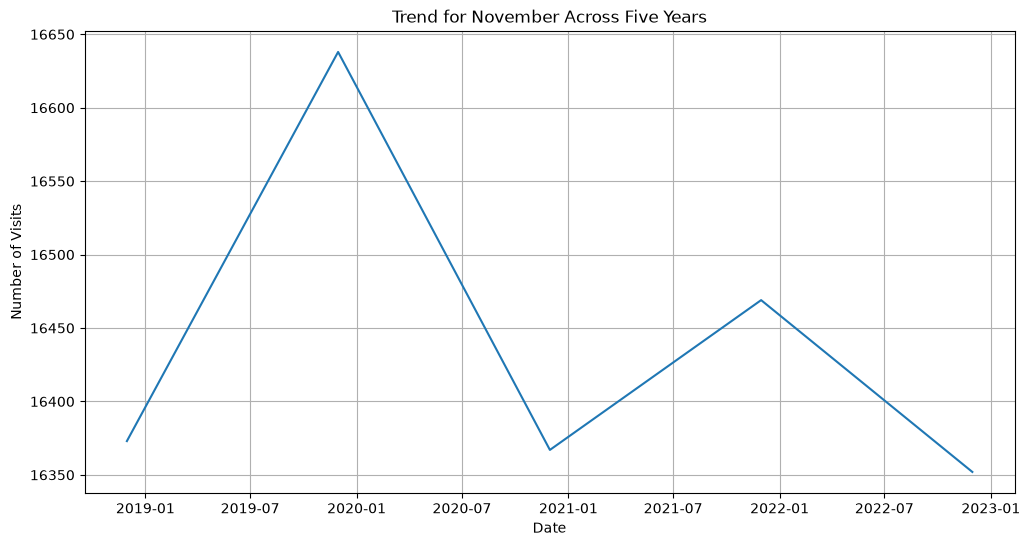

In [48]:
# visualize the trend for November
target_month = 11
df_target_month = df_resampled_month[df_resampled_month.index.month == target_month]
plt.figure(figsize=(12, 6))
plt.plot(df_target_month.index, df_target_month["Postcode"])
plt.title(f"Trend for {df_target_month.index[0].strftime("%B")} Across Five Years")
plt.xlabel("Date")
plt.ylabel("Number of Visits")
plt.grid(True)
plt.show()

## 07 Wait Time Analysis Pt. 1

In [49]:
df_visit = pd.read_csv(output_folder_path+"demo_hospital_outpatient_data_NHC_clean.zip")
df_visit.head()

,Visit_Date,Patient_ID,Age,Gender,Diagnosis,Has_Insurance,Postcode,Total_Cost,Registration_Minutes,Nursing_Minutes,Laboratory_Minutes,Consultation_Minutes,Pharmacy_Minutes
0,2020-05-06,688923,68,Female,Diabetes,True,20006,2274.0,33,105,101,28,112
1,2018-08-04,886361,62,Female,Urinary Tract Infection,False,20005,3430.0,46,75,84,102,36
2,2021-04-10,464823,70,Female,Upper Respiratory Tract Infection,True,10003,1836.0,107,81,5,77,36
3,2021-10-01,655214,8,Female,Upper Respiratory Tract Infection,False,10006,3250.0,66,31,101,35,92
4,2018-04-30,454666,24,Male,Malaria,True,10006,2262.0,68,55,60,90,104


In [51]:
# wait time information is available (in minutes) for five departments
# derive the total wait time for each visit, then save it in a column named 'Total_Minutes'
df_visit["Total_Minutes"] = df_visit["Registration_Minutes"] + df_visit["Nursing_Minutes"] + df_visit["Laboratory_Minutes"] + df_visit["Consultation_Minutes"] + df_visit["Pharmacy_Minutes"]
df_visit.head()

,Visit_Date,Patient_ID,Age,Gender,Diagnosis,Has_Insurance,Postcode,Total_Cost,Registration_Minutes,Nursing_Minutes,Laboratory_Minutes,Consultation_Minutes,Pharmacy_Minutes,Total_Minutes
0,2020-05-06,688923,68,Female,Diabetes,True,20006,2274.0,33,105,101,28,112,379
1,2018-08-04,886361,62,Female,Urinary Tract Infection,False,20005,3430.0,46,75,84,102,36,343
2,2021-04-10,464823,70,Female,Upper Respiratory Tract Infection,True,10003,1836.0,107,81,5,77,36,306
3,2021-10-01,655214,8,Female,Upper Respiratory Tract Infection,False,10006,3250.0,66,31,101,35,92,325
4,2018-04-30,454666,24,Male,Malaria,True,10006,2262.0,68,55,60,90,104,377


In [52]:
# derive the total wait time for each visit in hours, then save it in a column named 'Total_Hours'
df_visit["Total_Hours"] = df_visit["Total_Minutes"] / 60
df_visit.head()

,Visit_Date,Patient_ID,Age,Gender,Diagnosis,Has_Insurance,Postcode,Total_Cost,Registration_Minutes,Nursing_Minutes,Laboratory_Minutes,Consultation_Minutes,Pharmacy_Minutes,Total_Minutes,Total_Hours
0,2020-05-06,688923,68,Female,Diabetes,True,20006,2274.0,33,105,101,28,112,379,6.316667
1,2018-08-04,886361,62,Female,Urinary Tract Infection,False,20005,3430.0,46,75,84,102,36,343,5.716667
2,2021-04-10,464823,70,Female,Upper Respiratory Tract Infection,True,10003,1836.0,107,81,5,77,36,306,5.100000
3,2021-10-01,655214,8,Female,Upper Respiratory Tract Infection,False,10006,3250.0,66,31,101,35,92,325,5.416667
4,2018-04-30,454666,24,Male,Malaria,True,10006,2262.0,68,55,60,90,104,377,6.283333


In [53]:
# compute the average time per visit in hours
average_total_time_in_hours = df_visit["Total_Hours"].mean()
average_total_time_in_hours

np.float64(5.209838183333334)

In [54]:
# investigate which department has the highest average wait time
max_time_department = df_visit[["Registration_Minutes", "Nursing_Minutes", "Laboratory_Minutes", "Consultation_Minutes", "Pharmacy_Minutes"]].sum().idxmax()
max_time_department

'Registration_Minutes'

In [55]:
# the department with the highest average wait time is the Registration department
# what was the longest wait time in this department?
df_visit["Registration_Minutes"].max()

np.int64(120)

In [56]:
# what was the shortest wait time in the Registration department?
df_visit["Registration_Minutes"].min()

np.int64(5)

## 08: Wait Time Analysis Pt. 2

In [57]:
# replicate the analysis for other departments by writing a function...
# ... that takes a data frame name and the column of interest as input...
# ... and returns a brief statement with descriptive statistics as output
def department_wait_time_statistics(df, wait_time_column):
    wait_time_minutes = df[wait_time_column]
    wait_time_hours = wait_time_minutes / 60

    min_time = wait_time_hours.min()
    max_time = wait_time_hours.max()
    mean_time = wait_time_hours.mean()
    median_time = wait_time_hours.median()
    std_dev = wait_time_hours.std()

    sentence = f"For the department '{wait_time_column}', wait times range from {min_time:.2f} hours to {max_time:.2f} hours. " \
    f"The average wait time is {mean_time:.2f} hours, with a median of {median_time:.2f} hours. " \
    f"The standard deviation is {std_dev:.2f} hours."

    return sentence

In [58]:
department_wait_time_statistics(df_visit, "Nursing_Minutes")

"For the department 'Nursing_Minutes', wait times range from 0.08 hours to 2.00 hours. The average wait time is 1.04 hours, with a median of 1.05 hours. The standard deviation is 0.56 hours."

In [59]:
# let's improve the function
def department_wait_time_statistics(df, department_name):
    if department_name not in df.columns:
        return f"Department '{department_name}' not found in the DataFrame."
    wait_time_minutes = df[department_name]
    wait_time_hours = wait_time_minutes / 60

    min_time = wait_time_hours.min()
    max_time = wait_time_hours.max()
    mean_time = wait_time_hours.mean()
    median_time = wait_time_hours.median()
    std_dev = wait_time_hours.std()

    sentence = f"For the department '{department_name}', wait times range from {min_time:.2f} hours to {max_time:.2f} hours. " \
    f"The average wait time is {mean_time:.2f} hours, with a median of {median_time:.2f} hours. " \
    f"The standard deviation is {std_dev:.2f} hours."

    return sentence

In [60]:
department_wait_time_statistics(df_visit, "Nursing_Seconds")

"Department 'Nursing_Seconds' not found in the DataFrame."

## 09: Correlation Analysis

In [ ]:
# correlation investigates the interdependence of variables
# let's visualize the correlation patterns in the numeric columns of the dataset

In [61]:
df_visit = pd.read_csv(output_folder_path+"demo_hospital_outpatient_data_NHC_clean.zip")
df_visit

,Visit_Date,Patient_ID,Age,Gender,Diagnosis,Has_Insurance,Postcode,Total_Cost,Registration_Minutes,Nursing_Minutes,Laboratory_Minutes,Consultation_Minutes,Pharmacy_Minutes
0,2020-05-06,688923,68,Female,Diabetes,True,20006,2274.0,33,105,101,28,112
1,2018-08-04,886361,62,Female,Urinary Tract Infection,False,20005,3430.0,46,75,84,102,36
2,2021-04-10,464823,70,Female,Upper Respiratory Tract Infection,True,10003,1836.0,107,81,5,77,36
3,2021-10-01,655214,8,Female,Upper Respiratory Tract Infection,False,10006,3250.0,66,31,101,35,92
4,2018-04-30,454666,24,Male,Malaria,True,10006,2262.0,68,55,60,90,104
...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,2018-09-30,385435,9,Male,Abdominal pain,True,10004,1458.0,80,52,11,42,58
999996,2020-05-08,117261,29,Female,Urinary Tract Infection,True,20009,1836.0,59,57,64,66,60
999997,2019-12-31,594613,39,Female,Upper Respiratory Tract Infection,False,10001,1930.0,10,14,69,14,86
999998,2019-11-04,152179,39,Female,Malaria,False,20006,3950.0,119,52,60,94,70


In [62]:
# corr() computes pairwise correlation of columns (excluding NA/null values)
# N.B. I had to include numeric columns only, as other data types where causing corr() to fail
columns_for_correlation = df_visit.select_dtypes(include=np.number).columns.tolist()
correlation_matrix = df_visit[columns_for_correlation].corr()
correlation_matrix

,Patient_ID,Age,Postcode,Total_Cost,Registration_Minutes,Nursing_Minutes,Laboratory_Minutes,Consultation_Minutes,Pharmacy_Minutes
Patient_ID,1.000000,-0.000282,-0.000894,-0.000919,-0.000644,0.000219,-0.000059,0.000355,0.001745
Age,-0.000282,1.000000,-0.000665,-0.000826,-0.000126,-0.000701,0.001574,-0.001797,-0.000964
Postcode,-0.000894,-0.000665,1.000000,-0.000118,0.001181,0.000303,-0.001502,-0.001095,-0.000755
Total_Cost,-0.000919,-0.000826,-0.000118,1.000000,0.317479,0.315883,0.315693,0.316039,0.314457
Registration_Minutes,-0.000644,-0.000126,0.001181,0.317479,1.000000,0.000430,-0.000526,0.001286,0.000708
Nursing_Minutes,0.000219,-0.000701,0.000303,0.315883,0.000430,1.000000,0.001344,0.001269,-0.001245
Laboratory_Minutes,-0.000059,0.001574,-0.001502,0.315693,-0.000526,0.001344,1.000000,-0.001155,-0.001232
Consultation_Minutes,0.000355,-0.001797,-0.001095,0.316039,0.001286,0.001269,-0.001155,1.000000,-0.002343
Pharmacy_Minutes,0.001745,-0.000964,-0.000755,0.314457,0.000708,-0.001245,-0.001232,-0.002343,1.000000


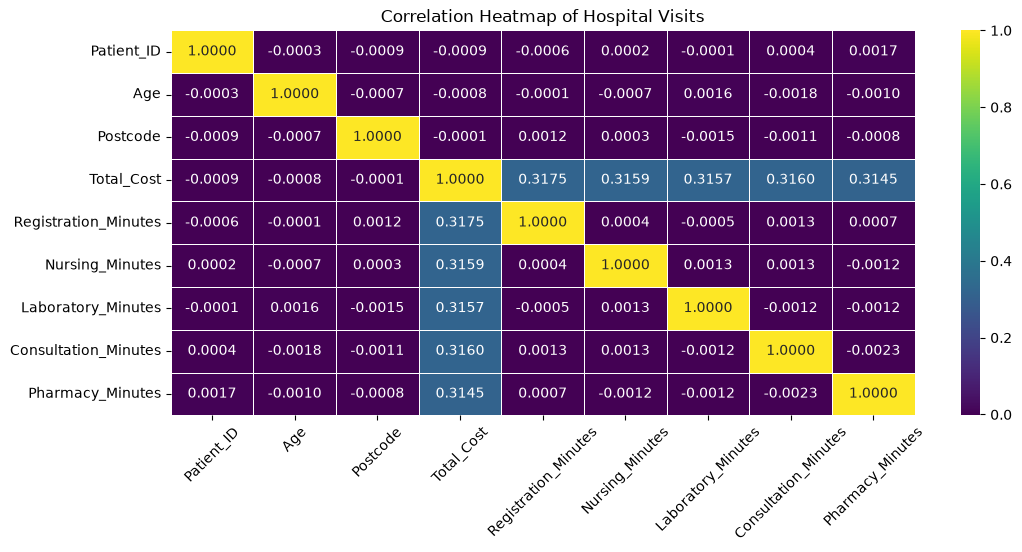

In [63]:
# visualize the correlation matrix as a heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(correlation_matrix, annot=True, cmap="viridis", fmt=".4f", linewidths=0.5)
plt.title("Correlation Heatmap of Hospital Visits")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# there seems to be a (slightly) positive correlation between 'Total_Cost' and wait time across departments

## 10: Cost and Insurance Analysis Pt. 1

In [64]:
df_visit = pd.read_csv(output_folder_path+"demo_hospital_outpatient_data_NHC_clean.zip")
df_visit.head()

,Visit_Date,Patient_ID,Age,Gender,Diagnosis,Has_Insurance,Postcode,Total_Cost,Registration_Minutes,Nursing_Minutes,Laboratory_Minutes,Consultation_Minutes,Pharmacy_Minutes
0,2020-05-06,688923,68,Female,Diabetes,True,20006,2274.0,33,105,101,28,112
1,2018-08-04,886361,62,Female,Urinary Tract Infection,False,20005,3430.0,46,75,84,102,36
2,2021-04-10,464823,70,Female,Upper Respiratory Tract Infection,True,10003,1836.0,107,81,5,77,36
3,2021-10-01,655214,8,Female,Upper Respiratory Tract Infection,False,10006,3250.0,66,31,101,35,92
4,2018-04-30,454666,24,Male,Malaria,True,10006,2262.0,68,55,60,90,104


In [65]:
# investigate whether there is any relationship between Gender and Total_Cost
avg_cost_by_gender = df_visit.groupby("Gender")["Total_Cost"].mean()
avg_cost_by_gender

Gender
Female    2627.048550
Male      2625.128996
Name: Total_Cost, dtype: float64

In [ ]:
# there seems to be no significant difference in 'Total_Cost' across genders

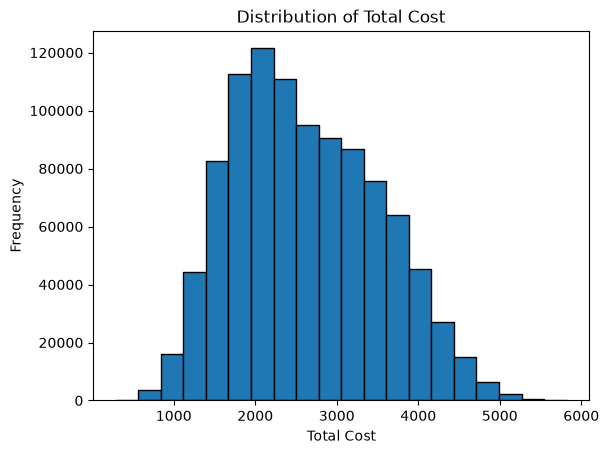

In [66]:
# visualize the distribution of Total_Cost as a histogram
plt.hist(df_visit["Total_Cost"], bins=20, edgecolor="k")
plt.title("Distribution of Total Cost")
plt.xlabel("Total Cost")
plt.ylabel("Frequency")
plt.show()

In [67]:
# investigate whether the cost varies based on the presence/absence of an insurance
avg_cost_by_insurance = df_visit[df_visit["Has_Insurance"] == True]["Total_Cost"].mean()
avg_cost_by_insurance

np.float64(1875.4243560527416)

In [68]:
avg_cost_without_insurance = df_visit[df_visit["Has_Insurance"] == False]["Total_Cost"].mean()
avg_cost_without_insurance

np.float64(3126.0332134366477)

In [ ]:
# without an insurance, the average cost is significantly higher

In [69]:
# investigate the pattern of Total_Cost over time
# to begin with, reformat the Visit_Date column
df_visit["Visit_Date"] = pd.to_datetime(df_visit["Visit_Date"])
df_visit.set_index("Visit_Date", inplace=True)
annual_total_cost = df_visit["Total_Cost"].resample("YE").sum()

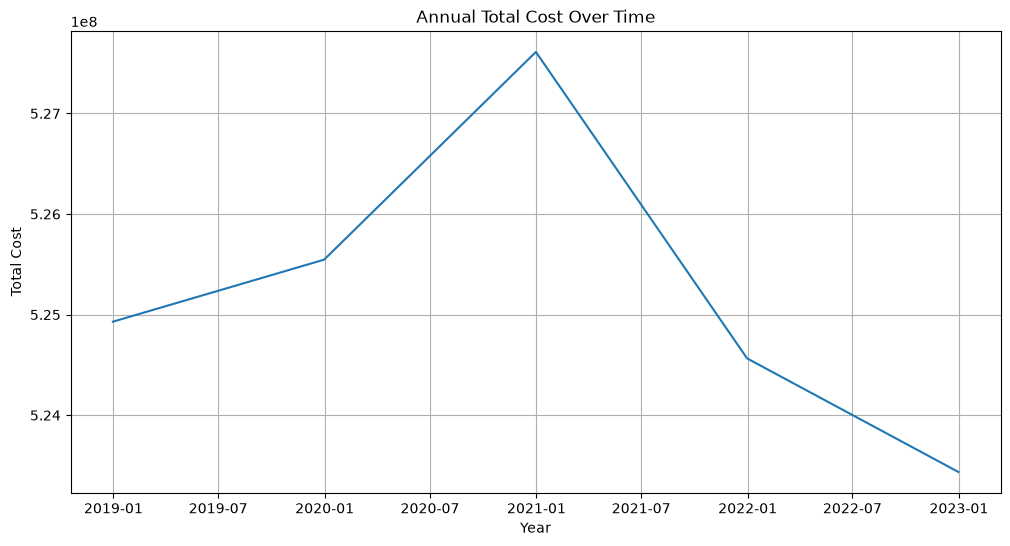

In [70]:
# visualize the pattern of Total_Cost over time
plt.figure(figsize=(12, 6))
plt.plot(annual_total_cost.index, annual_total_cost.values)
plt.title("Annual Total Cost Over Time")
plt.xlabel("Year")
plt.ylabel("Total Cost")
plt.grid(True)
plt.show()

## 11: Cost and Insurance Analysis Pt. 2

In [71]:
# index the data frame by Visit_Date (upon resetting the indexing)
df_visit = df_visit.reset_index()

In [72]:
df_visit.set_index("Visit_Date", inplace=True)
df_visit.head()

,Patient_ID,Age,Gender,Diagnosis,Has_Insurance,Postcode,Total_Cost,Registration_Minutes,Nursing_Minutes,Laboratory_Minutes,Consultation_Minutes,Pharmacy_Minutes
Visit_Date,,,,,,,,,,,,
2020-05-06,688923,68,Female,Diabetes,True,20006,2274.0,33,105,101,28,112
2018-08-04,886361,62,Female,Urinary Tract Infection,False,20005,3430.0,46,75,84,102,36
2021-04-10,464823,70,Female,Upper Respiratory Tract Infection,True,10003,1836.0,107,81,5,77,36
2021-10-01,655214,8,Female,Upper Respiratory Tract Infection,False,10006,3250.0,66,31,101,35,92
2018-04-30,454666,24,Male,Malaria,True,10006,2262.0,68,55,60,90,104


In [73]:
has_insurance_true_data = df_visit[df_visit["Has_Insurance"] == True]["Total_Cost"].resample("YE").sum()
has_insurance_false_data = df_visit[df_visit["Has_Insurance"] == False]["Total_Cost"].resample("YE").sum()

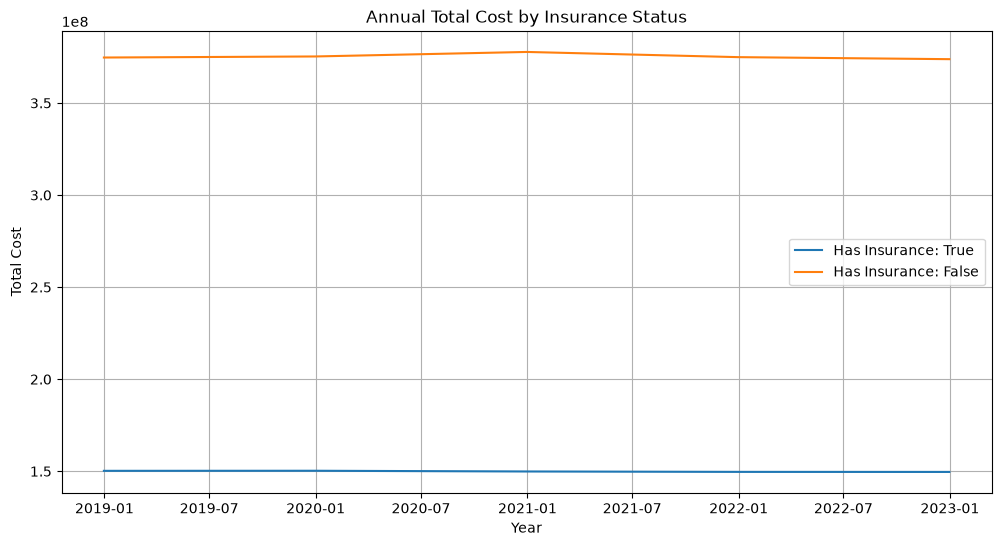

In [74]:
plt.figure(figsize=(12, 6))
plt.plot(has_insurance_true_data.index, has_insurance_true_data.values, label = "Has Insurance: True")
plt.plot(has_insurance_false_data.index, has_insurance_false_data.values, label = "Has Insurance: False")
plt.title("Annual Total Cost by Insurance Status")
plt.xlabel("Year")
plt.ylabel("Total Cost")
plt.grid(True)
plt.legend()
plt.show()